In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import brainmass
import brainstate
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Working with Units

`brainmass` uses `brainunit` for unit-safe computations, preventing common errors in scientific computing.

## Why Units Matter

Without units, it's easy to make mistakes:

In [2]:
# DANGEROUS: Are these in ms or s?
tau = 10
frequency = 0.5

# What happens when you multiply them?
result = tau * frequency  # Meaningless without units!

With units, errors are caught automatically:

In [3]:
import brainunit as u

tau = 10 * u.ms
frequency = 0.5 * u.Hz

# Units are checked automatically
result = tau * frequency  # ✓ Dimensionless (ms * Hz = ms * 1/s = 0.001)

## Basic Usage

### Creating Quantities

In [4]:
import brainunit as u
import jax.numpy as jnp

# Scalar with units
time_const = 10.0 * u.ms

# Array with units
rates = jnp.array([1.0, 2.0, 3.0]) * u.Hz

# Common units
voltage = -65 * u.mV
current = 2.5 * u.nA
capacitance = 100 * u.pF
conductance = 10 * u.nS
time = 1.5 * u.second

### Accessing Values and Units

In [5]:
tau = 10.0 * u.ms

# Get magnitude (number)
magnitude = tau.magnitude  # 10.0

# Get unit
unit = tau.unit  # millisecond

# Convert to different unit
tau_in_seconds = tau.to(u.second)  # 0.01 s
tau_in_us = tau.to(u.us)  # 10000 μs

### Unit Operations

In [6]:
import brainunit as u

# Addition/subtraction: units must match
t1 = 10 * u.ms
t2 = 5 * u.ms
t_sum = t1 + t2  # 15 ms ✓

t3 = 1 * u.second
t_combined = t1 + t3  # 1.01 s (automatic conversion) ✓

# Multiplication/division: units combine
R = 10 * u.ohm
I = 2 * u.amp
V = R * I  # 20 volt ✓

# Powers
area = (5 * u.meter) ** 2  # 25 meter²

## Common Units in Neuroscience

### Time

In [7]:
import brainunit as u

# Time constants
tau = 10 * u.ms  # milliseconds
tau_slow = 0.5 * u.second  # seconds

# Sampling intervals
dt = 0.1 * u.ms
TR = 2 * u.second  # fMRI repetition time

### Frequency

In [8]:
# Oscillation frequencies
alpha = 10 * u.Hz  # 10 Hz
theta = 5 * u.Hz
gamma = 40 * u.Hz

# Convert to angular frequency
omega = 2 * jnp.pi * alpha  # rad/s

### Voltage

In [9]:
# Membrane potentials
V_rest = -70 * u.mV
V_thresh = -55 * u.mV
V_spike = 20 * u.mV

# EEG potentials
eeg_signal = 50 * u.uvolt  # microvolts

### Current

In [10]:
# Synaptic currents
I_ext = 2.5 * u.pA  # picoamperes

# Dipole moments (EEG/MEG)
dipole = 10 * u.nA * u.meter  # nanoampere-meters

### Rate

In [11]:
# Firing rates
rate_E = 10 * u.Hz
rate_I = 15 * u.Hz

# Rates can be added
total_rate = rate_E + rate_I  # 25 Hz

## Using Units with brainmass

### Model Parameters

Most brainmass models accept unit quantities:

In [12]:
import brainmass
import brainunit as u

model = brainmass.WilsonCowanStep(
    in_size=10,
    tau_E=10. * u.ms,    # with units
    tau_I=20. * u.ms,
    # Recurrent coupling weights are dimensionless
    wEE=12.0,  # E -> E coupling strength
    wEI=13.0,  # I -> E coupling strength
)

### State Variables

Internal states maintain units:

In [13]:
model = brainmass.HopfStep(
    in_size=5,
    w=0.2,  # intrinsic angular frequency (dimensionless)
)
model.init_all_states()

model.update()

# In the normal-form Hopf model the state is dimensionless; models such as
# JansenRitStep instead keep their internal states in physical units (e.g. mV).
x = model.x.value
y = model.y.value

### Noise with Units

In [14]:
# Noise in Hz (for firing rates)
noise = brainmass.OUProcess(
    in_size=10,
    sigma=0.5 * u.Hz,
    tau=20 * u.ms,
)

# Noise in mV (for voltages)
noise_V = brainmass.OUProcess(
    in_size=10,
    sigma=5 * u.mV,
    tau=10 * u.ms,
)

### Forward Models

In [15]:
# BOLD (dimensionless or %)
bold = brainmass.BOLDSignal(in_size=90)
# Input: neural activity (Hz or dimensionless)
# Output: BOLD % signal change

# EEG lead-field: maps in_size sources -> out_size sensors.
# Real lead-fields come from a head model; here we use a synthetic one.
# Shape is (in_size, out_size) and it carries units of volt / (nA * meter).
L_eeg = jnp.ones((68, 64)) * (u.volt / (u.nA * u.meter))

eeg_model = brainmass.EEGLeadFieldModel(
    in_size=68,
    out_size=64,
    L=L_eeg,  # with units
)

## Unit Checking and Errors

### Automatic Error Detection

In [16]:
import brainunit as u

tau = 10 * u.ms
rate = 5 * u.Hz

# This will raise a unit-mismatch error:
try:
    result = tau + rate  # Can't add time and frequency!
except u.UnitMismatchError as e:
    print(f"Error: {e}")

Error: Cannot calculate 
10 ms + 5 Hz, because units do not match: ms != Hz


### Common Unit Errors

**Error 1: Mixing incompatible units**

In [17]:
# WRONG: adding incompatible quantities raises an error
time = 10 * u.ms
voltage = 5 * u.mV
try:
    result = time + voltage  # Error: can't add ms and mV
except u.UnitMismatchError as e:
    print(f"Caught: {e}")

# CORRECT:
# Don't add incompatible quantities

Caught: Cannot calculate 
10 ms + 5 mV, because units do not match: ms != mV


**Error 2: Forgetting units**

In [18]:
# WRONG:
tau_E = 10 * u.ms
tau_I = 20  # forgot units!
ratio = tau_I / tau_E  # May work but wrong semantics

# CORRECT:
tau_E = 10 * u.ms
tau_I = 20 * u.ms
ratio = tau_I / tau_E  # 2.0 (dimensionless)

**Error 3: Unit conversion mistakes**

In [19]:
# WRONG:
tau_ms = 10  # assumed ms, but unclear
tau_s = tau_ms / 1000  # manual conversion, error-prone

# CORRECT:
tau = 10 * u.ms
tau_s = tau.to(u.second)  # 0.01 s, automatic

## Converting to Unitless

Sometimes you need plain numbers (for plotting, external libraries):

Text(0, 0.5, 'Signal')

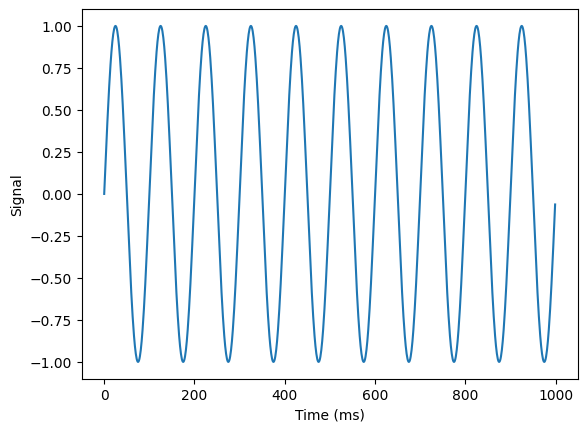

In [20]:
import brainunit as u
import matplotlib.pyplot as plt

time = jnp.arange(1000) * u.ms
# 2 * pi * (10 Hz) * time is dimensionless, so jnp.sin returns a plain array
signal = jnp.sin(2 * jnp.pi * 10 * u.Hz * time)

# Convert to unitless for plotting (u.get_magnitude works for Quantity or array)
time_ms = time.to(u.ms).magnitude  # array of numbers
signal_unitless = u.get_magnitude(signal)

plt.plot(time_ms, signal_unitless)
plt.xlabel('Time (ms)')
plt.ylabel('Signal')

Or use brainunit's plotting support:

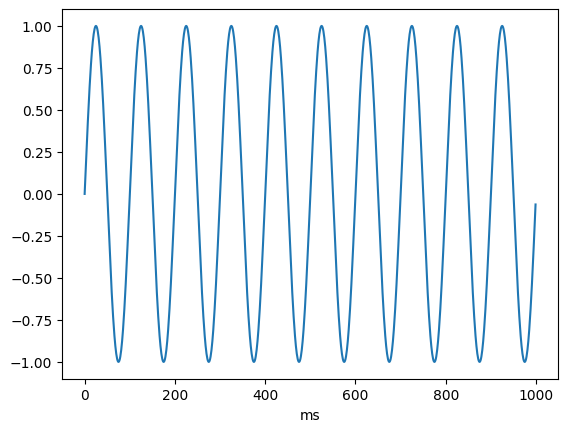

In [21]:
# Some plotting functions may support units directly
plt.plot(time, signal)  # may work with recent brainunit versions

## Best Practices

1. **Always use units for physical quantities**

In [22]:
# GOOD
tau = 10 * u.ms
frequency = 5 * u.Hz

# BAD
tau = 10  # unclear: ms? s?
frequency = 5  # unclear: Hz? kHz?

2. **Use consistent units within modules**

In [23]:
# Within a module, stick to one time unit
tau_E = 10 * u.ms
tau_I = 20 * u.ms  # not mixing with seconds
dt = 0.1 * u.ms

3. **Document units in comments when necessary**

In [24]:
# Even with brainunit, document expected ranges
tau = 10 * u.ms  # typical range: 5-50 ms

4. **Convert units explicitly when needed**

In [25]:
omega_Hz = 10 * u.Hz
omega_rad = 2 * jnp.pi * omega_Hz  # rad/s

# Convert time constant to frequency
tau = 10 * u.ms
f_cutoff = (1 / (2 * jnp.pi * tau)).to(u.Hz)

5. **Use dimensionless quantities appropriately**

In [26]:
# Ratios are naturally dimensionless
tau_E = 10 * u.ms
tau_I = 20 * u.ms
ratio = tau_I / tau_E  # 2.0 (dimensionless)

## Troubleshooting

**Issue: Dimension mismatch error**

In [27]:
# Error: DimensionMismatch: cannot add Hz and mV
# Solution: Check that you're not mixing incompatible quantities

**Issue: Lost units after JAX operations**

In [28]:
# Some JAX operations may strip units
x = 10 * u.ms
y = jnp.exp(x.magnitude)  # operate on the magnitude

# Solution: reattach units when the result is dimensionless
y = jnp.exp(x.magnitude) * u.UNITLESS

**Issue: Slow performance with units**

In [29]:
# Units add overhead; for tight loops, consider converting to unitless
tau_ms = tau.to(u.ms).magnitude  # convert once
# ... use tau_ms in loop ...

## Next Steps

- {doc}`quickstart` - See units in action
- {doc}`building_networks` - Units in network simulations
- `brainunit` documentation for advanced features

## See Also

- {doc}`../apis/models` - Model parameters and units
- {doc}`../apis/forward` - Forward model units